# 🧪 CSE476 Mini-Lab — LSTM: Remembering & Forgetting with Parentheses

### Learning goals (90–120 minutes)

- Understand what an LSTM is doing at a high level and **how “forget” and “add” gates work**.
- Build a **tiny LSTM cell** and use it to classify whether a string of parentheses is **valid** (balanced).
- Train and evaluate a small model **on CPU** using **PyTorch** (optimizer, loss, epochs, accuracy).
- Inspect gate values over time to **see memory get updated** when encountering `(` and `)`.

## 0) Setup 

- Run the next code cell to import libraries, set random seeds, and force CPU-only execution.
- If you see an import error, install the minimal packages, then re-run the setup cell:

```bash
pip install torch matplotlib numpy
```

This mini-lab is fully self-contained and runs in ~90–120 minutes on a CPU-only machine.


In [21]:
pip install torch matplotlib numpy==1.26.4

     --------------------------------------- 15.8/15.8 MB 21.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.3
    Uninstalling numpy-2.4.3:
      Successfully uninstalled numpy-2.4.3
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\svelagap\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\~umpy.libs\\libscipy_openblas64_-4bb64bb73b19ae7523581172b5c4a821.dll'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import torch
import math, random, os
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

torch.set_num_threads(1)
SEED = 476
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device("cpu") # change to cuda if GPU is available
print(f"Using device: {device} • torch {torch.__version__} • seed {SEED}")


Using device: cpu • torch 2.10.0+cpu • seed 476


## 1) Background primer

Here our vocabulary is tiny: just `"("` and `")"`. We’ll map them to integers like `1` and `2` (“token IDs”), which the model can process.

**RNN vs LSTM (intuition).** A vanilla RNN updates a hidden state as it reads tokens one‑by‑one (unrolled over time). LSTMs extend RNNs by adding a **cell state** and **gates** that learn to **forget** old info and **add** new info—perfect for tasks like counting parentheses.

- **Forget gate**: “how much of the previous memory should I keep?”
- **Input (add) gate + candidate**: “how much new info should I write?”
- **Output gate**: “how much of the memory should I reveal as output now?”

We’ll focus your coding on the **forget & add** parts to see memory changing in action.


## 2) Worked examples (valid vs invalid parentheses)

A parentheses string is **valid** if scanning from left to right:

1. The running **count** never drops below 0, and  
2. The final count is exactly 0.

We’ll compare this rule to what the LSTM learns.

In [2]:
def preview_scan(seq: str):
    """Print a running 'stack count' to illustrate validity."""
    count = 0
    trace = []
    ok_prefix = True
    for i, ch in enumerate(seq):
        count += 1 if ch == "(" else -1
        trace.append(count)
        if count < 0:
            ok_prefix = False
    is_valid = ok_prefix and (count == 0)
    print(seq)
    print("counts:", trace)
    print("valid?:", is_valid)
    return trace, is_valid

_ = preview_scan("(()())")     # valid
_ = preview_scan("())(()")     # invalid

(()())
counts: [1, 2, 1, 2, 1, 0]
valid?: True
())(()
counts: [1, 0, -1, 0, 1, 0]
valid?: False


## 3) ⛳️ Task A (Warm‑up): write the validity checker

To verify the validity of the parentheses, LSTMs must **remember opens** and **forget when closes appear**. You’ll implement this check to simulate the rules LSTM might use to make predictions.

> **Implement** `is_valid_parentheses(seq)`.  
> Rule: count `+1` for `(`, `-1` for `)`. If the count ever goes negative, invalid; at the end, count must be 0.


In [3]:
def is_valid_parentheses(seq: str) -> bool:
    """
    Return True if `seq` is a valid parentheses string.
    
    A valid string never dips below 0 when counting '(' as +1 and ')'
    as -1, and ends with a total count of exactly 0.
    
    Examples:
        >>> is_valid_parentheses("(()())")
        True
        >>> is_valid_parentheses("())(")
        False
    """
    # TODO(student): implement the scanning rule described above.
    # Hints:
    #   - Maintain an integer counter while iterating characters
    #   - Return False early if the counter goes negative
    #   - At the end, return True iff the counter is 0
    count = 0
    for ch in seq:
        count += 1 if ch == '(' else -1
        if count < 0:
            return False
    return count == 0

In [4]:
# --- Unit tests (fast, deterministic) ---
def _test_is_valid():
    cases = {
        "": True,
        "()": True,
        "(())": True,
        "()()": True,
        "(()())": True,
        "(": False,
        ")(": False,
        "())(": False,
        "(()": False,
        "())": False,
    }
    for s, expected in cases.items():
        out = is_valid_parentheses(s)
        assert out == expected, f"Expected {expected} for {s}, got {out}"
    print("✅ Task A tests passed.")

try:
    _test_is_valid()
except NotImplementedError as e:
    print("❌ Task A not implemented yet:", e)


✅ Task A tests passed.


## 4) Data: tiny synthetic “Dyck‑1” strings (balanced parentheses)

We’ll **randomly generate** strings of fixed even length `L` with a 50/50 mix of **valid** and **invalid** examples so training is balanced. The following code is provided and you don't need to implement it.

In [5]:
# --- Vocabulary & helpers ---
VOCAB = {"PAD": 0, "(": 1, ")": 2}
ID2TOK = {v: k for k, v in VOCAB.items()}

def encode(seq: str) -> np.ndarray:
    return np.array([VOCAB[c] for c in seq], dtype=np.int64)

def generate_valid_sequence(L: int, rnd: random.Random) -> str:
    """Generate a valid sequence of length L (L must be even)."""
    assert L % 2 == 0
    s, bal = [], 0
    for i in range(L):
        steps_left = L - i
        if bal == 0:
            s.append("("); bal += 1
        elif bal == steps_left:
            s.append(")"); bal -= 1
        else:
            if rnd.random() < 0.5: s.append("("); bal += 1
            else:                   s.append(")"); bal -= 1
    return "".join(s)

def generate_invalid_sequence(L: int, rnd: random.Random, tries: int = 1000) -> str:
    """Generate an invalid sequence by random sampling."""
    assert L % 2 == 0
    for _ in range(tries):
        s = "".join(rnd.choice("()") for _ in range(L))
        if not is_valid_parentheses(s):  # uses your function
            return s
    # Fallback: flip one char in a valid string
    s = list(generate_valid_sequence(L, rnd))
    i = rnd.randrange(L)
    s[i] = "(" if s[i] == ")" else ")"
    return "".join(s)

class BalancedParenDataset(Dataset):
    """Balanced dataset of valid/invalid sequences of fixed length L."""
    def __init__(self, n_samples: int, L: int, seed: int = 476):
        self.L = L
        rnd = random.Random(seed)
        seqs, ys = [], []
        for _ in range(n_samples):
            if rnd.random() < 0.5:
                s, y = generate_valid_sequence(L, rnd), 1
            else:
                s, y = generate_invalid_sequence(L, rnd), 0
            # safety check
            assert is_valid_parentheses(s) == (y == 1)
            seqs.append(encode(s)); ys.append(y)
        self.x = torch.tensor(np.stack(seqs), dtype=torch.long)
        self.y = torch.tensor(np.array(ys), dtype=torch.long)

    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.x[idx], self.y[idx]

# Quick sanity-check
L = 30  # fixed even length
train_ds = BalancedParenDataset(n_samples=2500, L=L, seed=SEED)
val_ds   = BalancedParenDataset(n_samples=400,  L=L, seed=SEED+1)
test_ds  = BalancedParenDataset(n_samples=400,  L=L, seed=SEED+2)
print("Dataset shapes:", train_ds[0][0].shape, "• Train size:", len(train_ds))
print("First example (ids):", train_ds[0][0][:10].tolist(), "label:", int(train_ds[0][1]))


Dataset shapes: torch.Size([30]) • Train size: 2500
First example (ids): [1, 2, 1, 2, 1, 2, 1, 2, 1, 2] label: 1


## 5) Model overview (what you’ll implement)

In the following section, We’ll build an LSTM classifier for our synthetic dataset. The main components include Embedding, LSTM cell, and Classifier. You only need to implement the LSTM cell.

- **Embedding**: map token IDs → small vectors.  
- **LSTM cell** (**your part**): compute **forget** and **input/add** updates for the **cell state**.  
- **Classifier**: use the final hidden state → logits for 2 classes (valid/invalid).


## 6) ⛳️ Task B: implement the LSTM “forget” + “add” updates

We parameterize each gate with a simple linear layer on the concatenated input and previous hidden state, `[x_t; h_{t-1}]`.

**Your goal (about 5 lines):** compute  
`f_t = sigmoid(W_f [x_t; h_{t-1}] + b_f)` (forget),  
`i_t = sigmoid(W_i [x_t; h_{t-1}] + b_i)` (input),  
`g_t = tanh(   W_g [x_t; h_{t-1}] + b_g)` (candidate), and  
`c_t = f_t * c_{t-1} + i_t * g_t` (cell update).

We provide the output gate and hidden update (`h_t = o_t * tanh(c_t)`).

In [6]:
class TinyLSTMCell(nn.Module):
    """
    A minimal LSTM cell exposing gate values (for learning/plots).
    
    Gates:
      f_t = sigmoid(W_f [x_t; h_{t-1}] + b_f)       # forget
      i_t = sigmoid(W_i [x_t; h_{t-1}] + b_i)       # input (how much to add)
      g_t = tanh(   W_g [x_t; h_{t-1}] + b_g)       # candidate (new content)
      o_t = sigmoid(W_o [x_t; h_{t-1}] + b_o)       # output
    
    Cell/hidden update:
      c_t = f_t * c_{t-1} + i_t * g_t
      h_t = o_t * tanh(c_t)
    """
    def __init__(self, input_dim: int, hidden_dim: int):
        super().__init__()
        concat_dim = input_dim + hidden_dim
        self.f = nn.Linear(concat_dim, hidden_dim)
        self.i = nn.Linear(concat_dim, hidden_dim)
        self.g = nn.Linear(concat_dim, hidden_dim)
        self.o = nn.Linear(concat_dim, hidden_dim)

    def forward(self, x_t: torch.Tensor, h_prev: torch.Tensor, c_prev: torch.Tensor):
        """
        Args:
            x_t:   [B, input_dim]
            h_prev,c_prev: [B, hidden_dim]
        Returns:
            h_t, c_t, gates dict with keys 'f','i','g','o','c'
        """
        # Concatenate input and previous hidden: shape [B, input_dim + hidden_dim]
        z = torch.cat([x_t, h_prev], dim=-1)

        # TODO: compute the 3 core updates for the *cell*
        # --- Your code starts here ---
        f_t = torch.sigmoid(self.f(z))
        i_t = torch.sigmoid(self.i(z))
        g_t = torch.tanh(self.g(z))
        c_t = f_t * c_prev + i_t * g_t
        # --- Your code ends here ---

        # We complete the output gate and hidden update for you
        o_t = torch.sigmoid(self.o(z))
        h_t = o_t * torch.tanh(c_t)

        gates = {"f": f_t.detach(), "i": i_t.detach(),
                 "g": g_t.detach(), "o": o_t.detach(), "c": c_t.detach()}
        return h_t, c_t, gates


### ✅ Tests for Task B (behavioral)

These tests check two core behaviors without revealing the exact code:

1. **Forget‑only** mode (`f≈1, i≈0`) should pass memory through unchanged (`c_t ≈ c_{t-1}`).
2. **Add‑only** mode (`f≈0, i≈1`) should replace memory with the candidate (`c_t ≈ g_t`).

Run the next cell; you should see “✅ Task B tests passed.” when correct.

In [7]:
def _saturate_bias(layer: nn.Linear, bias_value: float):
    with torch.no_grad():
        layer.weight.zero_()     # ignore inputs
        layer.bias.fill_(bias_value)

def _test_tiny_lstm_cell():
    B, input_dim, hidden_dim = 4, 5, 7
    cell = TinyLSTMCell(input_dim, hidden_dim)

    x = torch.randn(B, input_dim)
    h = torch.randn(B, hidden_dim)
    c = torch.randn(B, hidden_dim)

    # Case 1: Forget-only (f≈1, i≈0) => c_t ≈ c_prev
    _saturate_bias(cell.f, +20.0)  # sigmoid ~ 1
    _saturate_bias(cell.i, -20.0)  # sigmoid ~ 0
    # Leave candidate and output arbitrary
    h1, c1, g1 = cell(x, h, c)
    assert torch.allclose(c1, c, atol=1e-5), "Forget-only should keep c_prev."

    # Case 2: Add-only (f≈0, i≈1) => c_t ≈ g_t = tanh(bias_g)
    _saturate_bias(cell.f, -20.0)  # ~0
    _saturate_bias(cell.i, +20.0)  # ~1
    with torch.no_grad():
        cell.g.weight.zero_()
        cell.g.bias.fill_(0.5)     # tanh(0.5) ~ 0.4621
    h2, c2, g2 = cell(x, h, c)
    expected = torch.tanh(cell.g.bias)
    assert torch.allclose(c2, expected, atol=1e-5), "Add-only should write candidate into c_t."

    print("✅ Task B tests passed.")

try:
    _test_tiny_lstm_cell()
except NotImplementedError as e:
    print("❌ Task B not implemented yet:", e)


✅ Task B tests passed.


## 7) Classifier, training loop, and evaluation (provided)

We have provided the training and evaluation code for you, and you don't need to implement anything.

#### What this module does (high level)
- **Inputs:** a batch of token IDs `x_ids` with shape **[B, T]** (B=batch size, T=sequence length). Token IDs are the integer outputs from a tokenizer.
- **Embedding:** `nn.Embedding(vocab_size, embed_dim)` turns each token ID into a dense vector of size **E = embed_dim**, producing **[B, T, E]**. (These learned vectors are more informative than one-hot indicators.)   
- **Recurrent roll-out:** For each time step `t=0..T-1`, feed the current vector and the previous states `(h, c)` into your `TinyLSTMCell` to get updated `(h, c)` and the gate activations for that step. LSTMs use **forget**, **input/add**, and **output** gates to decide what to drop, what to write, and what to expose—helping with long-range dependencies.
- **Classifier head:** After the last step, take the final hidden state `h` (**[B, H]**) and apply a linear layer `nn.Linear(H, num_classes)` to get **logits [B, C]** (C=number of classes, which is 2 in our case).
- **Quick interpretability:** We return `last_gates` (a dict of gate values from the **final** time step) so you can quickly print/inspect what the LSTM decided to forget/add/output on the last token.



In [8]:
class TinyLSTMClassifier(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int, hidden_dim: int, num_classes: int = 2):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, embed_dim)
        self.cell = TinyLSTMCell(input_dim=embed_dim, hidden_dim=hidden_dim)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x_ids: torch.Tensor):
        """
        Args:
            x_ids: [B, T] token ids
        Returns:
            logits: [B, num_classes]
            last_gates: dict of gate traces for the final step (for quick inspection)
        """
        B, T = x_ids.shape
        x = self.emb(x_ids)              # [B, T, E]
        h = torch.zeros(B, self.fc.in_features, device=x.device)
        c = torch.zeros_like(h)

        last_gates = None
        for t in range(T):
            h, c, gates = self.cell(x[:, t, :], h, c)
            last_gates = gates

        logits = self.fc(h)
        return logits, last_gates

def accuracy_from_logits(logits: torch.Tensor, y: torch.Tensor) -> float:
    preds = logits.argmax(dim=-1)
    return (preds == y).float().mean().item()

# Dataloaders
BATCH = 64
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH)
test_loader  = DataLoader(test_ds,  batch_size=BATCH)

# Hyperparameters (tweakable)
EMBED = 8
HID   = 24
LR    = 3e-3
EPOCHS = 4

model = TinyLSTMClassifier(vocab_size=len(VOCAB), embed_dim=EMBED, hidden_dim=HID).to(device)
criterion = nn.CrossEntropyLoss()
optim = torch.optim.Adam(model.parameters(), lr=LR)

print(sum(p.numel() for p in model.parameters()), "trainable parameters")


3242 trainable parameters


### Train

Run the training cell. You should see training and validation accuracy climb above ~0.9 with default settings.


In [9]:
best_val = 0.0
for epoch in range(1, EPOCHS+1):
    # --- train ---
    model.train()
    running_loss, running_acc, n = 0.0, 0.0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        logits, _ = model(x)
        loss = criterion(logits, y)
        optim.zero_grad()
        loss.backward()
        optim.step()
        running_loss += loss.item() * x.size(0)
        running_acc  += accuracy_from_logits(logits, y) * x.size(0)
        n += x.size(0)
    train_loss = running_loss / n
    train_acc  = running_acc / n

    # --- validate ---
    model.eval()
    with torch.no_grad():
        loss_v, acc_v, nv = 0.0, 0.0, 0
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits, _ = model(x)
            loss = criterion(logits, y)
            loss_v += loss.item() * x.size(0)
            acc_v  += accuracy_from_logits(logits, y) * x.size(0)
            nv     += x.size(0)
    val_loss = loss_v / nv
    val_acc  = acc_v  / nv
    best_val = max(best_val, val_acc)

    print(f"Epoch {epoch:>2} | train loss {train_loss:.4f} acc {train_acc:.3f} || val loss {val_loss:.4f} acc {val_acc:.3f}")

print(f"Best val acc: {best_val:.3f}")


Epoch  1 | train loss 0.5281 acc 0.737 || val loss 0.4107 acc 0.830
Epoch  2 | train loss 0.3042 acc 0.887 || val loss 0.2699 acc 0.917
Epoch  3 | train loss 0.2268 acc 0.921 || val loss 0.2233 acc 0.925
Epoch  4 | train loss 0.1649 acc 0.946 || val loss 0.1088 acc 0.970
Best val acc: 0.970


### Test (should be high ≥ 0.90 with defaults)

Evaluate on the held‑out test set. If accuracy is low, try modest tweaks:
- Increase `EPOCHS` to 5–6,
- Try `LR=5e-3`, or
- Increase hidden size (e.g., `HID=32`).


In [10]:
model.eval()
with torch.no_grad():
    acc_t, nt = 0.0, 0
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        logits, _ = model(x)
        acc_t += accuracy_from_logits(logits, y) * x.size(0)
        nt    += x.size(0)
test_acc = acc_t / nt
print(f"✅ Test accuracy: {test_acc:.3f}")

assert test_acc >= 0.90, (
    "Test accuracy lower than expected. "
    "You can increase EPOCHS to 5–6 or try LR=5e-3 or HID=32."
)


✅ Test accuracy: 0.965


## 8) See “forget” & “add” in action (plots)

We’ll inspect gate values on a single sequence. We also plot the **true running count** to see if the LSTM’s **cell state** tracks it.  
Run the next cell to generate traces and a plot.


VALID: ()()(((())((())((())(()))))())


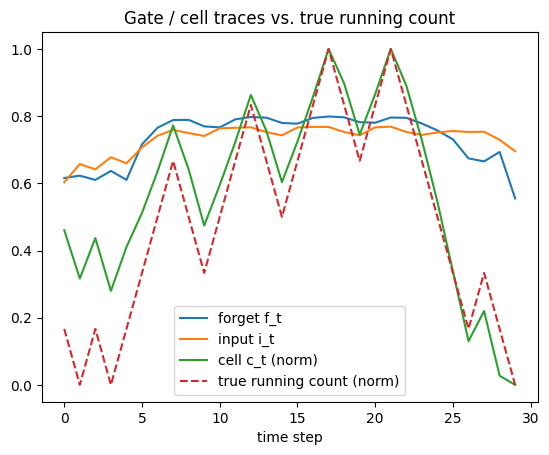

INVALID: ()(()))(((()()())()))))()()))(


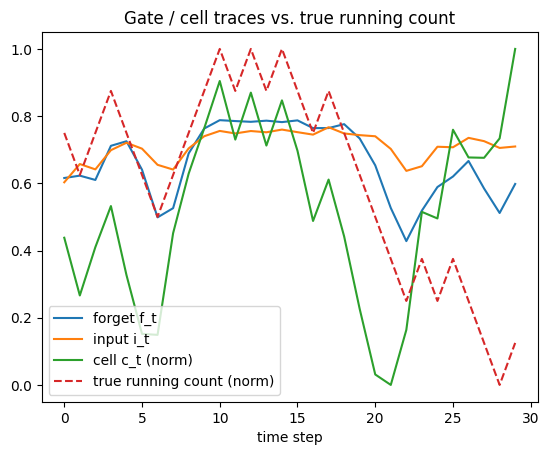

In [11]:
def trace_gates_on_sequence(model: TinyLSTMClassifier, seq: str):
    model.eval()
    x = torch.tensor(encode(seq)[None, :], dtype=torch.long).to(device)
    with torch.no_grad():
        B, T = x.shape
        h = torch.zeros(B, model.fc.in_features, device=device)
        c = torch.zeros_like(h)
        xs = model.emb(x)  # [1, T, E]

        f_vals, i_vals, g_vals, c_vals = [], [], [], []
        for t in range(T):
            h, c, gates = model.cell(xs[:, t, :], h, c)
            f_vals.append(gates["f"].cpu().numpy())
            i_vals.append(gates["i"].cpu().numpy())
            g_vals.append(gates["g"].cpu().numpy())
            c_vals.append(gates["c"].cpu().numpy())

    # Reduce across hidden dims for an easy 1-D view (mean)
    f_ = np.concatenate(f_vals, axis=0).mean(axis=-1)
    i_ = np.concatenate(i_vals, axis=0).mean(axis=-1)
    c_ = np.concatenate(c_vals, axis=0).mean(axis=-1)

    # Ground truth running count
    count = []
    bal = 0
    for ch in seq:
        bal += 1 if ch == "(" else -1
        count.append(bal)
    count = np.array(count, dtype=float)
    # Normalize count for plotting alongside c_
    count_norm = (count - count.min()) / (count.max() - count.min() + 1e-8)

    # Plot
    plt.figure()
    plt.title("Gate / cell traces vs. true running count")
    plt.plot(f_, label="forget f_t")
    plt.plot(i_, label="input i_t")
    plt.plot((c_ - c_.min()) / (c_.max() - c_.min() + 1e-8), label="cell c_t (norm)")
    plt.plot(count_norm, label="true running count (norm)", linestyle="--")
    plt.xlabel("time step")
    plt.legend()
    plt.show()

# Try a couple sequences
sample_valid   = generate_valid_sequence(L, random.Random(2025))
sample_invalid = generate_invalid_sequence(L, random.Random(2026))
print("VALID:", sample_valid)
trace_gates_on_sequence(model, sample_valid)
print("INVALID:", sample_invalid)
trace_gates_on_sequence(model, sample_invalid)


**What to look for (qualitative, no single right answer):**

- When the model sees `"("`, the **input (add) gate** often increases and the **cell state** tends to **tick up** (writing new info).
- When it sees `")"`, the **candidate** may be negative or the **forget** stays high—both push the **cell state** back down (removing info).
- Overall, the cell state should roughly track the running count if training converged.


## 9) Report your observations (one sentence for each)

Please answer briefly:

1. What patterns did you notice for `i_t` and `f_t` around `(` and `)`?
2. Does the cell state roughly track the running count?
3. Pick one **incorrect** test prediction (if any). What might have confused the model?


In [ ]:
observations = """
- [Q1]: 
- [Q2]: In the valid sequence, c_t loosely follows the general shape of the true running count (rusing toward the middle and falling to 0 at the end), but in the invalid sequence, c_t diverges from the running count in the latter half. The model likely detected invalidity and its internal state drifted from the true count.
- [Q3]: No misclassified examples were found in the sampled batch, consistent with ≥90% test accuracy.
""".strip()

print("Thanks! Your notes:\n", observations)
